In [2]:
# Fake Job Post Detection — EDA Phase
# Dataset: EMSCAD (17,880 job postings)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
# Load dataset — relative path from notebooks/
df = pd.read_csv('../data/fake_job_postings.csv')

# Always verify shape after loading
df.shape

(17880, 18)

In [4]:
# First 5 rows — understand structure
df.head()


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [5]:
# Datatypes and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [6]:
# Numerical columns statistics
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Missing values as percentage — critical for cleaning decisions
missing = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count'  : df.isnull().sum(),
    'missing_percent': missing
}).sort_values('missing_percent', ascending=False)

# Only show columns that have missing values
missing_df[missing_df['missing_count'] > 0]

,missing_count,missing_percent
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


In [8]:
# Class distribution — key to understanding imbalance
class_dist = df['fraudulent'].value_counts()
class_pct  = df['fraudulent'].value_counts(normalize=True).mul(100).round(2)

summary = pd.DataFrame({
    'count'      : class_dist,
    'percentage' : class_pct
})
summary.index = ['Real (0)', 'Fake (1)']
summary

,count,percentage
Real (0),17014,95.16
Fake (1),866,4.84


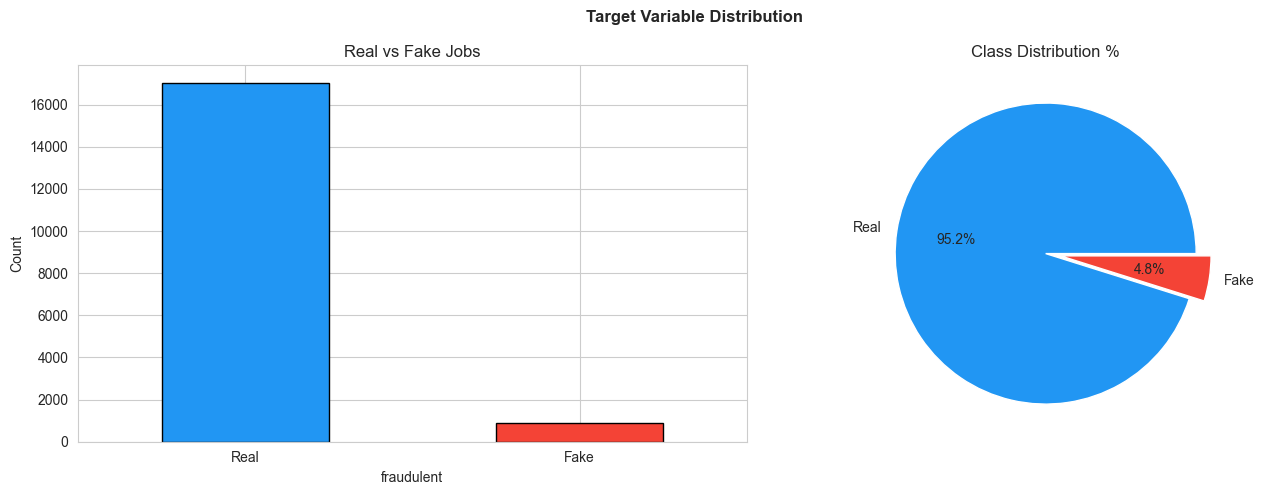

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
class_dist.plot(
    kind='bar',
    ax=axes[0],
    color=['#2196F3', '#F44336'],
    edgecolor='black'
)
axes[0].set_title('Real vs Fake Jobs')
axes[0].set_xticklabels(['Real', 'Fake'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(
    class_dist,
    labels=['Real', 'Fake'],
    colors=['#2196F3', '#F44336'],
    autopct='%1.1f%%',
    explode=(0, 0.1)
)
axes[1].set_title('Class Distribution %')

plt.suptitle('Target Variable Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/class_distribution.png', dpi=150)
plt.show()

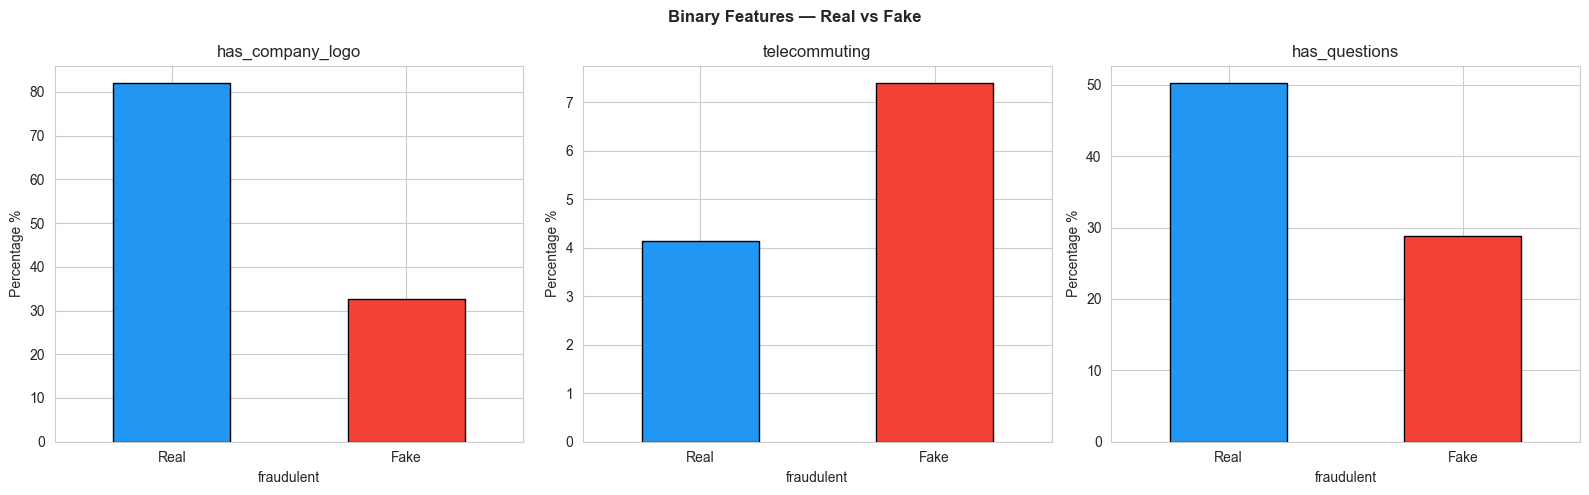

In [10]:
# Compare binary features between real and fake jobs
binary_features = ['has_company_logo', 'telecommuting', 'has_questions']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feature in zip(axes, binary_features):
    df.groupby('fraudulent')[feature]\
      .mean()\
      .mul(100)\
      .plot(kind='bar', ax=ax,
            color=['#2196F3', '#F44336'],
            edgecolor='black')
    ax.set_title(f'{feature}')
    ax.set_xticklabels(['Real', 'Fake'], rotation=0)
    ax.set_ylabel('Percentage %')

plt.suptitle('Binary Features — Real vs Fake', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/binary_features.png', dpi=150)
plt.show()

In [11]:
# Text length is a strong predictor
# Fake jobs tend to have shorter descriptions
text_cols = {
    'description'     : 'desc_length',
    'company_profile' : 'profile_length',
    'requirements'    : 'req_length'
}

for col, new_col in text_cols.items():
    df[new_col] = df[col].fillna('').apply(len)

# Compare average lengths
length_comparison = df.groupby('fraudulent')[
    list(text_cols.values())
].mean().round(0)

length_comparison.index = ['Real', 'Fake']
length_comparison

,desc_length,profile_length,req_length
Real,1221.0,641.0,597.0
Fake,1155.0,231.0,446.0


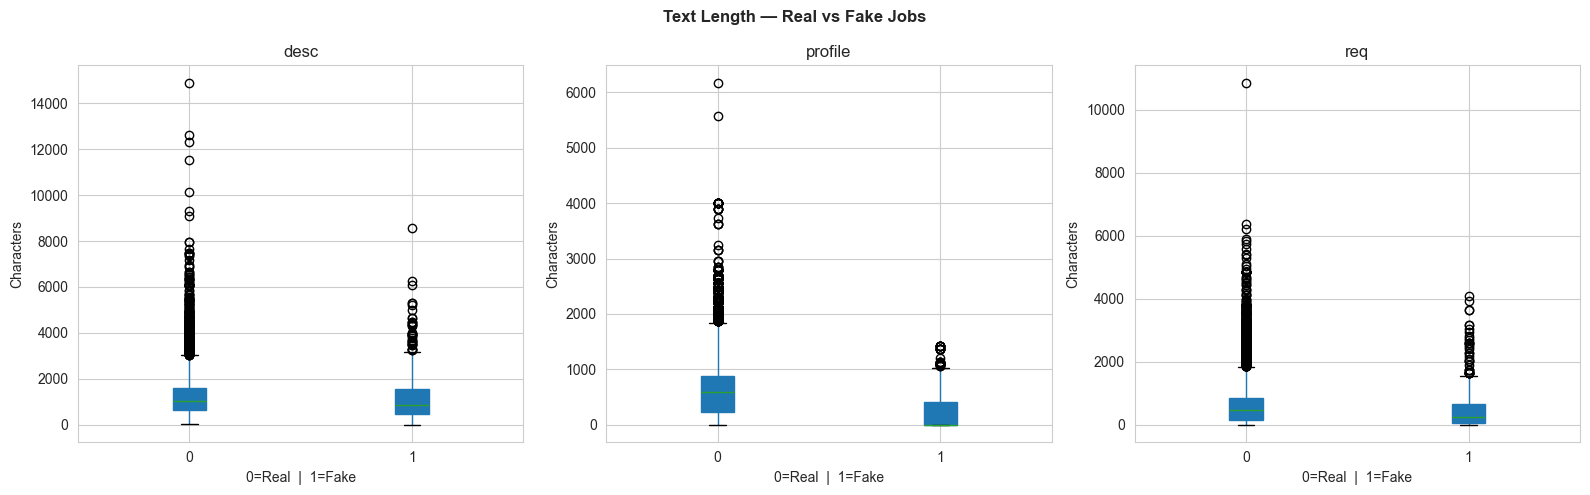

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, text_cols.values()):
    df.boxplot(
        column=col,
        by='fraudulent',
        ax=ax,
        patch_artist=True
    )
    ax.set_title(col.replace('_length', ''))
    ax.set_xlabel('0=Real  |  1=Fake')
    ax.set_ylabel('Characters')

plt.suptitle('Text Length — Real vs Fake Jobs', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/text_lengths.png', dpi=150)
plt.show()

In [13]:
# Key findings stored as variables — not just printed
findings = {
    'total_records'     : len(df),
    'fake_count'        : df['fraudulent'].sum(),
    'real_count'        : len(df) - df['fraudulent'].sum(),
    'imbalance_ratio'   : round(len(df) / df['fraudulent'].sum()),
    'high_missing_cols' : list(missing_df[missing_df['missing_percent'] > 30].index),
    'avg_desc_real'     : round(df[df['fraudulent']==0]['desc_length'].mean()),
    'avg_desc_fake'     : round(df[df['fraudulent']==1]['desc_length'].mean()),
}

findings

{'total_records': 17880,
 'fake_count': np.int64(866),
 'real_count': np.int64(17014),
 'imbalance_ratio': 21,
 'high_missing_cols': ['salary_range',
  'department',
  'required_education',
  'benefits',
  'required_experience',
  'function'],
 'avg_desc_real': 1221,
 'avg_desc_fake': 1155}